<a href="https://colab.research.google.com/github/Harnzt/Analisis-dan-Visualisasi-Data/blob/main/marketing_campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya visualisasi
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

# **Load Dataset**

In [5]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')

In [6]:
display(df.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

# **Data Cleaning & Feature Engineering**

In [8]:
# 1. Menghapus baris yang memiliki nilai kosong (biasanya ada di kolom Income)
df = df.dropna()

# 2. Menghitung Umur Pelanggan (menggunakan tahun saat ini 2026)
df['Age'] = 2026 - df['Year_Birth']

# 3. Menggabungkan jumlah anak
df['Total_Kids'] = df['Kidhome'] + df['Teenhome']

# 4. Menghitung Total Pengeluaran (MntTotal) selama 2 tahun terakhir
df['Total_Spent'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + \
                    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# 5. Menghitung Total Pembelian dari berbagai platform
df['Total_Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

# 6. Menghapus outlier pada umur dan pendapatan agar tidak merusak model
df = df[(df['Age'] < 90) & (df['Income'] < 200000)]

# 7. Membuang kolom yang sudah tidak diperlukan atau berlebihan
cols_to_drop = ['ID', 'Year_Birth', 'Z_CostContact', 'Z_Revenue', 'Dt_Customer',
                'Kidhome', 'Teenhome', 'AcceptedCmp1', 'AcceptedCmp2',
                'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df_cleaned = df.drop(columns=cols_to_drop)

print("Data siap diproses. Dimensi data saat ini:", df_cleaned.shape)

Data siap diproses. Dimensi data saat ini: (2212, 20)


# **Preprocessing Data**

In [9]:
# Memisahkan kolom kategorikal dan numerik
categorical_cols = ['Education', 'Marital_Status']

# Label Encoding untuk kolom kategorikal
le = LabelEncoder()
for col in categorical_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col])

# Normalisasi data menggunakan StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cleaned)

# Membuat dataframe baru dari data yang sudah diskalakan
df_scaled = pd.DataFrame(scaled_features, columns=df_cleaned.columns)

# **Reduksi Dimensi (PCA)**

In [10]:
# Menggunakan PCA untuk mereduksi dimensi menjadi 3
pca = PCA(n_components=3)
pca_data = pca.fit_transform(df_scaled)

# Membuat DataFrame dari hasil PCA
pca_df = pd.DataFrame(data=pca_data, columns=['PCA1', 'PCA2', 'PCA3'])
print("Varians yang dijelaskan oleh 3 komponen PCA:", pca.explained_variance_ratio_.sum())

Varians yang dijelaskan oleh 3 komponen PCA: 0.5548418293947895


# **Evaluasi Model**

--- Memulai Komparasi Model Clustering ---

Hasil Evaluasi Silhouette Score (Semakin mendekati 1 semakin baik):
1. K-Means Score: 0.346
2. Agglomerative Score: 0.319
3. DBSCAN Score: 0.241


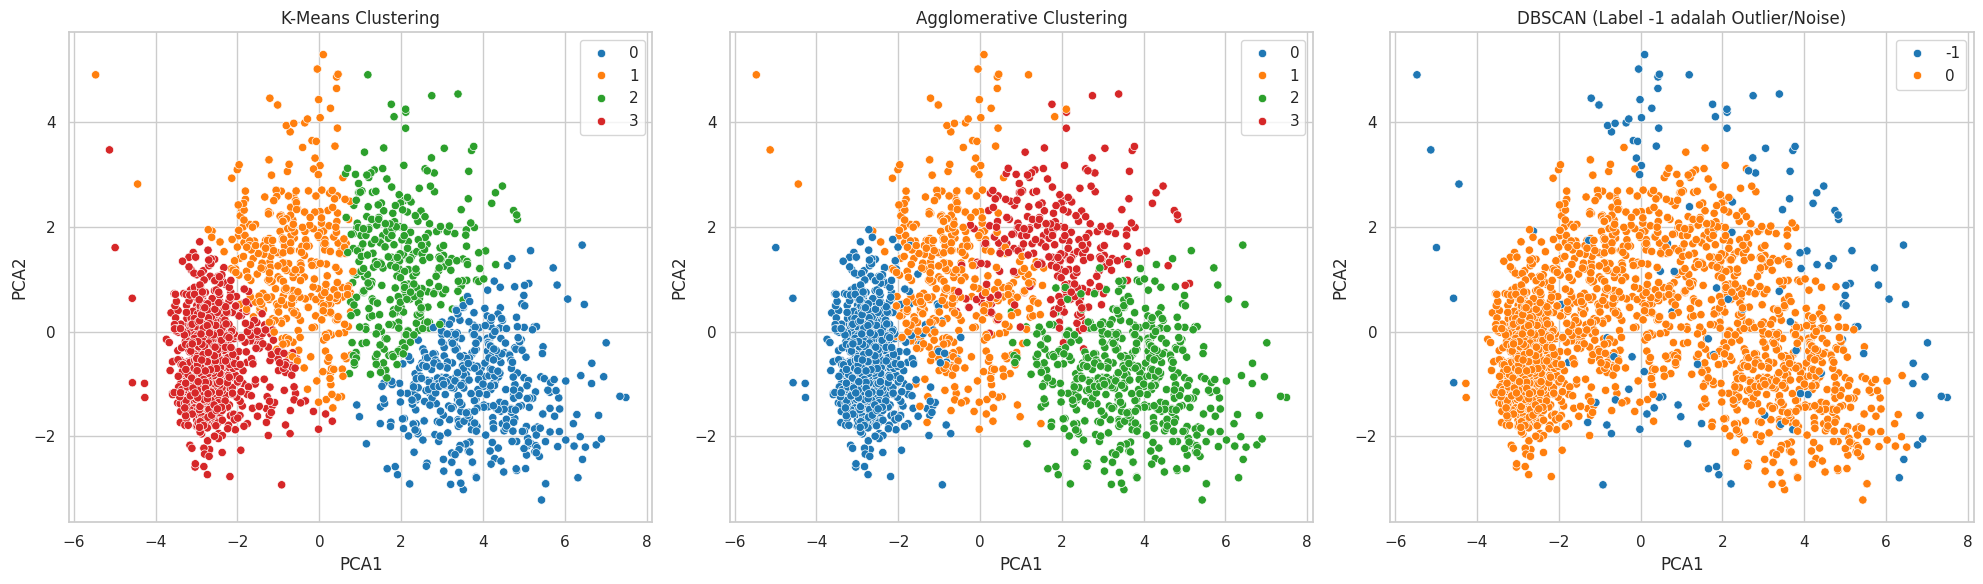


Jumlah pelanggan yang dianggap aneh/outlier oleh DBSCAN: 147 orang dari total data.


In [11]:
print("--- Memulai Komparasi Model Clustering ---")

# 1. K-Means Clustering (Kita gunakan 4 cluster seperti sebelumnya)
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(pca_data)

# 2. Agglomerative (Hierarchical) Clustering
agglo = AgglomerativeClustering(n_clusters=4)
agglo_labels = agglo.fit_predict(pca_data)

# 3. DBSCAN Clustering
# eps: jarak maksimal antar 2 sampel agar dianggap satu kelompok
# min_samples: jumlah minimal data dalam satu lingkungan untuk membentuk cluster
dbscan = DBSCAN(eps=0.8, min_samples=10)
dbscan_labels = dbscan.fit_predict(pca_data)

# Evaluasi menggunakan Silhouette Score (Semakin mendekati 1 semakin baik)
print("\nHasil Evaluasi Silhouette Score:")
print(f"1. K-Means Score: {silhouette_score(pca_data, kmeans_labels):.3f}")
print(f"2. Agglomerative Score: {silhouette_score(pca_data, agglo_labels):.3f}")

# DBSCAN terkadang membuat semua data menjadi noise (-1) atau hanya 1 cluster,
# yang membuat fungsi silhouette error, jadi kita gunakan try-except
try:
    dbscan_score = silhouette_score(pca_data, dbscan_labels)
    print(f"3. DBSCAN Score: {dbscan_score:.3f}")
except ValueError:
    print("3. DBSCAN Score: Tidak bisa dihitung (Hanya terbentuk 1 cluster atau mayoritas noise).")

# Visualisasi Komparasi (Kita gunakan PCA1 dan PCA2 agar bentuk 2D mudah dilihat)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot K-Means
sns.scatterplot(x=pca_df['PCA1'], y=pca_df['PCA2'], hue=kmeans_labels, palette='tab10', ax=axes[0], legend='full')
axes[0].set_title('K-Means Clustering')

# Plot Agglomerative
sns.scatterplot(x=pca_df['PCA1'], y=pca_df['PCA2'], hue=agglo_labels, palette='tab10', ax=axes[1], legend='full')
axes[1].set_title('Agglomerative Clustering')

# Plot DBSCAN
sns.scatterplot(x=pca_df['PCA1'], y=pca_df['PCA2'], hue=dbscan_labels, palette='tab10', ax=axes[2], legend='full')
axes[2].set_title('DBSCAN (Label -1 adalah Outlier/Noise)')

plt.tight_layout()
plt.show()

# Menampilkan jumlah data yang dianggap Outlier oleh DBSCAN
outliers = list(dbscan_labels).count(-1)
print(f"\nJumlah pelanggan yang dianggap aneh/outlier oleh DBSCAN: {outliers} orang dari total data.")

# **Analisis Karakteristik Segmen**

,Age,Income,Total_Spent,Total_Purchases,Total_Kids
Cluster,,,,,
0,56.96,77216.92,1413.09,19.46,0.15
1,59.65,50899.00,454.91,13.61,1.31
2,61.67,64572.54,1039.32,20.41,0.94
3,54.29,34212.73,80.70,5.46,1.21


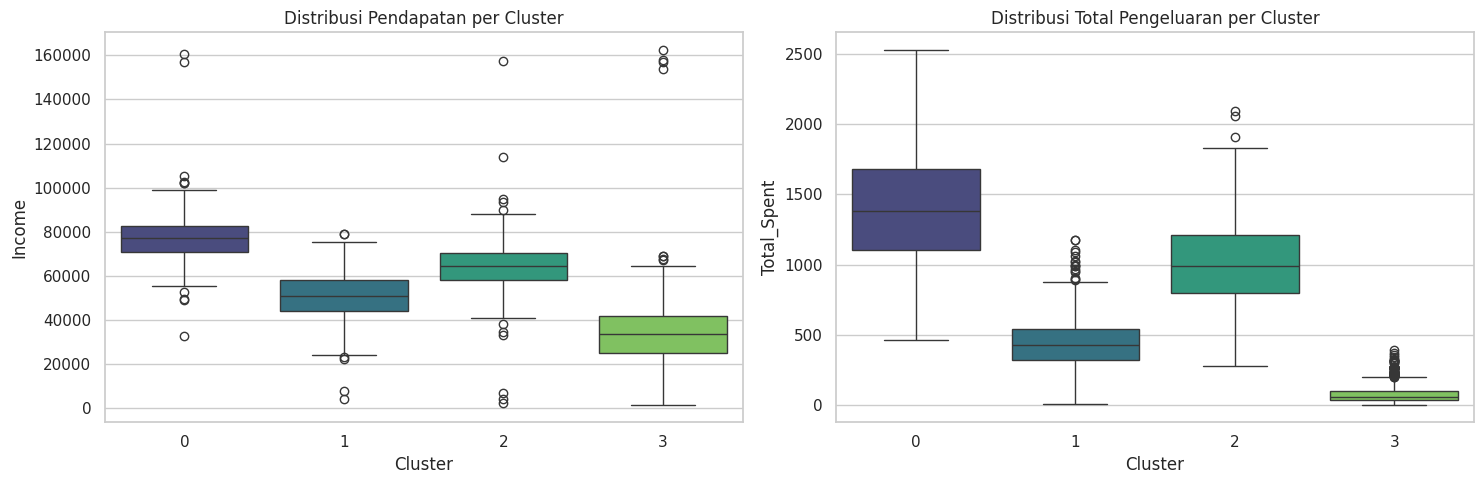

In [22]:
# Profiling karakteristik masing-masing cluster
df['Cluster'] = kmeans_labels # Add cluster labels to the DataFrame
cluster_profile = df.groupby('Cluster')[['Age', 'Income', 'Total_Spent', 'Total_Purchases', 'Total_Kids']].mean().round(2)

display(cluster_profile)

# Visualisasi perbandingan Income dan Total Spent antar Cluster
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x='Cluster', y='Income', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Pendapatan per Cluster')

sns.boxplot(x='Cluster', y='Total_Spent', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Distribusi Total Pengeluaran per Cluster')

plt.tight_layout()
plt.show()

# **Kesimpulan**

**1. Faktor Penentu Utama Belanja (Korelasi)**

* **Pendapatan vs Pengeluaran:** Pendapatan (`Income`) berbanding lurus dengan daya beli. Semakin tinggi gaji pelanggan, semakin besar nominal uang yang dihabiskan (`Total_Spent`) dan semakin sering mereka berbelanja (`Total_Purchases`).
* **Jumlah Anak vs Pengeluaran:** Tanggungan anak (`Total_Kids`) berbanding terbalik dengan pengeluaran sekunder. Pelanggan dengan banyak anak cenderung menahan pengeluarannya.

**2. Karakteristik 4 Segmen Pelanggan**

* **Cluster 0:** Ini adalah kelompok paling menguntungkan. Di usia 57 tahun, mereka memiliki pendapatan tertinggi (77.216) dan berbelanja paling banyak (1413). Mereka memiliki paling sedikit tanggungan anak (0.15).
* **Cluster 1:** Kelompok yang paling sensitif terhadap harga. Mereka adalah demografi usia dengan rata-rata 59 tahun dengan pendapatan 50.899 dan tanggungan anak terbanyak (1.31). Pengeluaran mereka sangat kecil termasuk kecil dibandingkan dengan selisih pendapatan (455).
* **Cluster 2:** Pelanggan paling berumur (~61 tahun) dengan tingkat pendapatan (64.572) dan tingkat belanja paling banyak kedua (1039).
* **Cluster 3:**
Kelompok yang paling sensitif terhadap harga. Mereka adalah demografi termuda diantara cluster (~54 tahun) dengan pendapatan terendah (34.212) dan tanggungan anak terbanyak kedua (1.21). Pengeluaran mereka sangat kecil (86.85).

**Rekomendasi Bisnis Ringkas:**
Fokuskan promosi produk premium atau barang mewah kepada **Cluster 0 dan 2** karena mereka memiliki daya beli tinggi dan minim tanggungan. Sebaliknya, berikan promosi berupa diskon, kupon, atau produk paket hemat (kebutuhan keluarga) kepada **Cluster 1 dan 3**.